# Climate Risk-Aware Planting Recommendation Model
### Stochastic Simulation + Machine Learning — Nyagatare District, Rwanda


This notebook covers the ML-pipeline

1. **Data visualization & engineering** — real Meteo Rwanda ENACTS dekadal climate data (1981–2023)
2. **Stochastic risk layer** — two-state Markov chain weather generator + Monte Carlo simulation
3. **Model architecture** — rule-based baseline vs Decision Trees vs XGBoost (3-class planting-window suitability)
4. **Initial performance metrics** — macro F1, balanced accuracy, Brier score, confusion matrices, feature importance

> The deployed companion (FastAPI + Swagger UI + web page) is in `app.py` 

In [ ]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent          
sys.path.insert(0, str(ROOT / "src"))
FIG = ROOT / "docs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
GREEN, AMBER, RED = "#1b7a43", "#b87b00", "#b3372b"

from data_loader import load, temperature_pools
df = load()
print(f"{len(df)} dekads | {df.year.min()}–{df.year.max()} | "
      f"mean annual rainfall {df.groupby('year').rainfall_mm.sum().mean():.0f} mm")
df.head()

1543 dekads | 1981–2023 | mean annual rainfall 933 mm


,date,year,month,dekad_of_year,abs_dekad,rainfall_mm,tmax_c,tmin_c
0,1981-01-01,1981,1,1,720,24.47059,22.86169,12.90544
1,1981-01-11,1981,1,2,721,10.87783,24.54681,12.88619
2,1981-01-21,1981,1,3,722,13.90498,23.70454,13.20620
3,1981-02-01,1981,2,4,723,15.46606,23.47768,13.04146
4,1981-02-11,1981,2,5,724,18.48416,22.84312,13.25336


## 1 · Data: Meteo Rwanda ENACTS (real, not synthetic)

Three dekadal (10-day) series spatially averaged over the Nyagatare box
(X 30.0–30.6, Y −1.5 to −1.05), downloaded from the
[Meteo Rwanda Maproom](http://maproom.meteorwanda.gov.rw):

| series | period | source product |
|---|---|---|
| rainfall | 1981–2023 | Merged station–satellite rainfall |
| max temperature | 1961–2021 | Gridded Tmax |
| min temperature | 1961–2016 | Gridded Tmin |

**Data engineering:** the raw ENACTS `Time` labels (`"1-10 Jan 1981"`) are parsed
into `(year, month, dekad)`, missing codes (−99) dropped, the three series merged,
and a continuous `abs_dekad` index added so crop cycles can run across year
boundaries (a 120-day maize cycle planted in November ends in February).

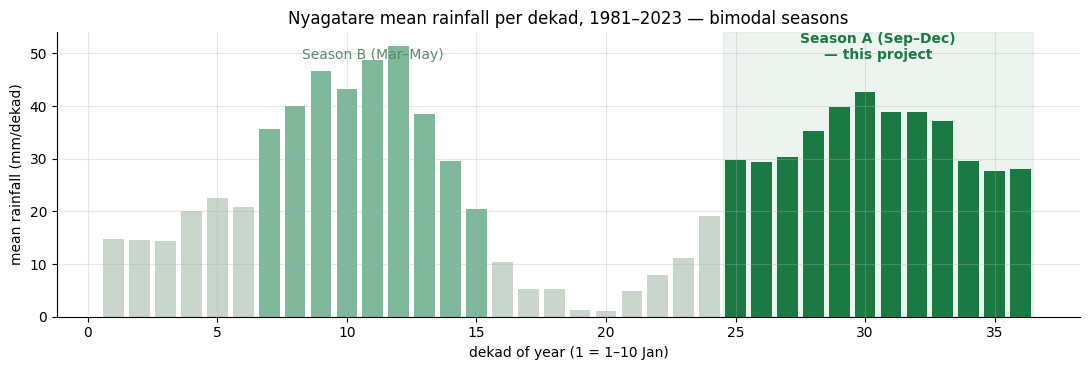

In [2]:
# Annual rainfall cycle — Nyagatare's bimodal climate
clim = df.groupby("dekad_of_year").rainfall_mm.mean()
fig, ax = plt.subplots(figsize=(11, 3.8))
colors = [GREEN if 25 <= d <= 36 else ("#7fb89a" if 7 <= d <= 15 else "#c8d6cc") for d in clim.index]
ax.bar(clim.index, clim.values, color=colors)
ax.axvspan(24.5, 36.5, alpha=.08, color=GREEN)
ax.text(30.5, clim.max()*.95, "Season A (Sep–Dec)\n— this project", ha="center", color=GREEN, fontweight="bold")
ax.text(11, clim.max()*.95, "Season B (Mar–May)", ha="center", color="#5a8a6e")
ax.set(xlabel="dekad of year (1 = 1–10 Jan)", ylabel="mean rainfall (mm/dekad)",
       title="Nyagatare mean rainfall per dekad, 1981–2023 — bimodal seasons")
plt.tight_layout(); plt.savefig(FIG / "annual_cycle.png", bbox_inches="tight"); plt.show()

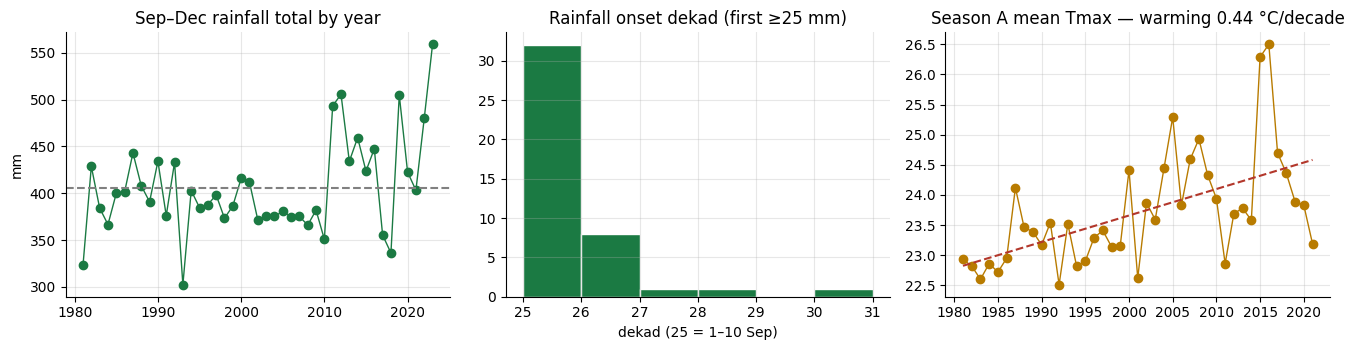

The warming trend matters: 2015–2017 heat drove many 'risky' outcomes in the test set.


In [3]:
# Season A totals and rainfall onset per year
from features import yearly_features
yf = yearly_features(df)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
axes[0].plot(yf.year, yf.sond_total_mm, "o-", color=GREEN, lw=1)
axes[0].axhline(yf.sond_total_mm.mean(), ls="--", c="gray")
axes[0].set(title="Sep–Dec rainfall total by year", ylabel="mm")
axes[1].hist(yf.onset_dekad, bins=range(25, 32), color=GREEN, edgecolor="white")
axes[1].set(title="Rainfall onset dekad (first ≥25 mm)", xlabel="dekad (25 = 1–10 Sep)")
ok = yf.dropna(subset=["sond_tmax_mean"])
axes[2].plot(ok.year, ok.sond_tmax_mean, "o-", color=AMBER, lw=1)
z = np.polyfit(ok.year, ok.sond_tmax_mean, 1)
axes[2].plot(ok.year, np.polyval(z, ok.year), "--", color=RED)
axes[2].set(title=f"Season A mean Tmax — warming {z[0]*10:.2f} °C/decade")
plt.tight_layout(); plt.savefig(FIG / "season_overview.png", bbox_inches="tight"); plt.show()
print("The warming trend matters: 2015–2017 heat drove many 'risky' outcomes in the test set.")

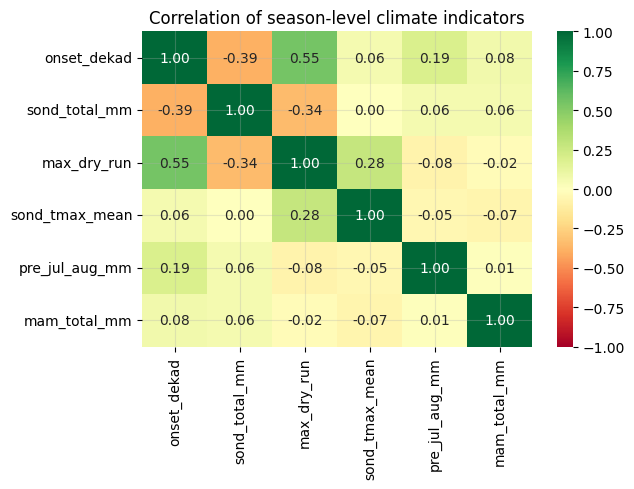

In [4]:
# Correlations between season-level indicators
corr = yf[["onset_dekad", "sond_total_mm", "max_dry_run",
           "sond_tmax_mean", "pre_jul_aug_mm", "mam_total_mm"]].corr()
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, vmin=-1, vmax=1)
plt.title("Correlation of season-level climate indicators")
plt.tight_layout(); plt.savefig(FIG / "correlations.png", bbox_inches="tight"); plt.show()

**Reading the EDA:** Season A delivers ~380 mm on average with real year-to-year
spread; onset is usually the first September dekad but slips into October in dry
years; and maximum temperature shows a clear warming trend. Later onset
correlates with lower season totals — the agronomic intuition the model should learn.

## 2 · Stochastic risk layer (Markov chain + Monte Carlo)

A two-state **Markov chain** models dekad wet/dry occurrence
(wet = ≥20 mm ≈ 2 mm/day at district average). Transition probabilities
P(wet | wet) and P(wet | dry) are estimated **per calendar month**; wet/dry-dekad
rainfall amounts are sampled from month-specific **empirical pools**
(non-parametric version of the proposal's Gamma option), and dekadal Tmax from
dekad-of-year pools.

The chain is **conditioned on the observed state at planting time**: the
preceding dekad sets the initial wet/dry state, a recent 3-dekad rainfall
anomaly nudges the first transitions (rainfall persistence, geometric decay),
and the observed May–Aug Tmax anomaly shifts simulated temperatures
(warm years persist).

**Monte Carlo:** 1,000 crop-cycle rainfall sequences are simulated per candidate
window and scored against documented crop requirements, giving the proposal's
risk features:

- `p_rain_sufficient` = P(cycle rainfall ≥ crop minimum)
- `p_dry_spell` = P(harmful establishment dry spell)
- `p_temp_stress` = P(cycle-mean Tmax warm anomaly)
- `risk_score` = 0.5·(1−p_rain_sufficient) + 0.3·p_dry_spell + 0.2·p_temp_stress

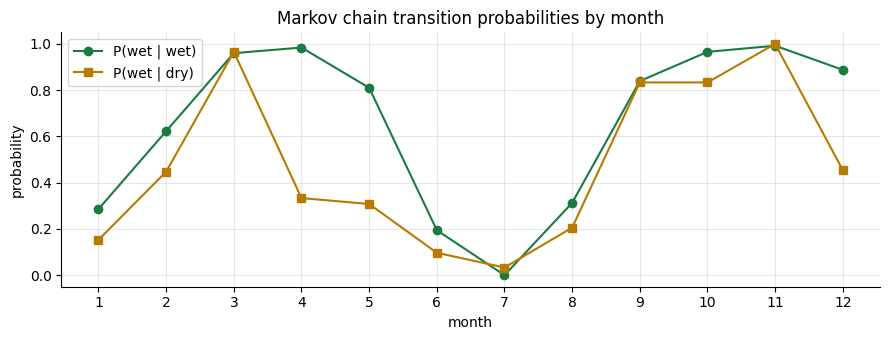

In [5]:
from simulate import WeatherGenerator
from crops import CROPS, PLANTING_WINDOWS, DEKAD_LABEL
gen = WeatherGenerator().fit(df, temperature_pools(df))

months = range(1, 13)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(months, [gen.p_wet_given_wet[m] for m in months], "o-", color=GREEN, label="P(wet | wet)")
ax.plot(months, [gen.p_wet_given_dry[m] for m in months], "s-", color=AMBER, label="P(wet | dry)")
ax.set(xticks=list(months), xlabel="month", ylabel="probability",
       title="Markov chain transition probabilities by month")
ax.legend(); plt.tight_layout(); plt.savefig(FIG / "markov_transitions.png", bbox_inches="tight"); plt.show()

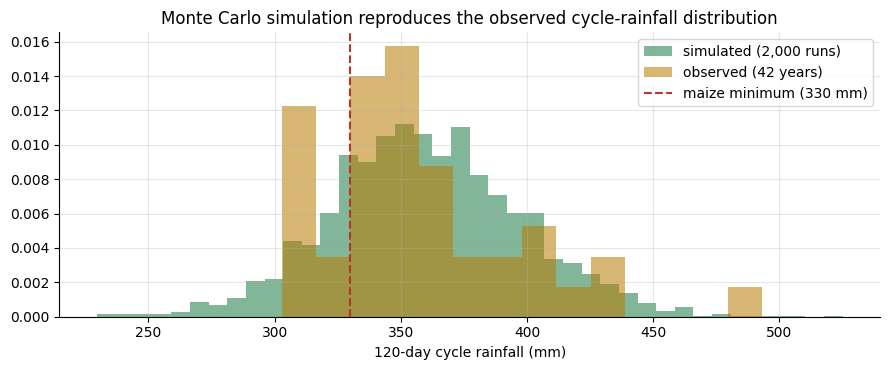

observed median 352 mm | simulated median 359 mm


In [6]:
# Generator validation: simulated vs observed maize-cycle rainfall (window 1–10 Oct)
from features import _abs
W, CYC = 28, CROPS["maize"]["cycle_dekads"]
rain_idx = df.set_index("abs_dekad").rainfall_mm
observed = [rain_idx.reindex(range(_abs(y, W), _abs(y, W) + CYC)).sum()
            for y in range(1981, 2023)]
observed = [o for o in observed if not np.isnan(o)]
sim, _, _ = gen.simulate(W, CYC, n_sims=2000, seed=42)
plt.figure(figsize=(9, 3.8))
plt.hist(sim.sum(axis=1), bins=40, density=True, alpha=.55, color=GREEN, label="simulated (2,000 runs)")
plt.hist(observed, bins=14, density=True, alpha=.55, color=AMBER, label=f"observed ({len(observed)} years)")
plt.axvline(CROPS["maize"]["min_cycle_mm"], color=RED, ls="--", label="maize minimum (330 mm)")
plt.legend(); plt.xlabel("120-day cycle rainfall (mm)")
plt.title("Monte Carlo simulation reproduces the observed cycle-rainfall distribution")
plt.tight_layout(); plt.savefig(FIG / "sim_validation.png", bbox_inches="tight"); plt.show()
print(f"observed median {np.median(observed):.0f} mm | simulated median {np.median(sim.sum(axis=1)):.0f} mm")

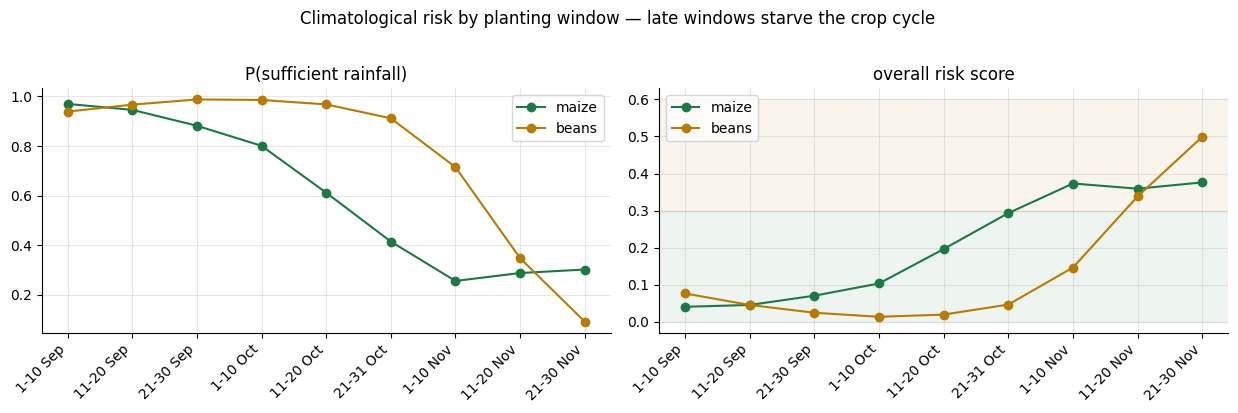

In [7]:
# Risk profile of every candidate planting window
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
for crop, c in [("maize", GREEN), ("beans", AMBER)]:
    rf = [gen.risk_features(crop, w, seed=w) for w in PLANTING_WINDOWS]
    axes[0].plot(PLANTING_WINDOWS, [r["p_rain_sufficient"] for r in rf], "o-", color=c, label=crop)
    axes[1].plot(PLANTING_WINDOWS, [r["risk_score"] for r in rf], "o-", color=c, label=crop)
labels = [DEKAD_LABEL[w] for w in PLANTING_WINDOWS]
for ax, t in zip(axes, ["P(sufficient rainfall)", "overall risk score"]):
    ax.set_xticks(PLANTING_WINDOWS); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(t); ax.legend()
axes[1].axhspan(0, .3, color=GREEN, alpha=.07); axes[1].axhspan(.3, .6, color=AMBER, alpha=.07)
plt.suptitle("Climatological risk by planting window — late windows starve the crop cycle", y=1.02)
plt.tight_layout(); plt.savefig(FIG / "risk_by_window.png", bbox_inches="tight"); plt.show()

## 3 · Labels and the ML training table

One row per **(year × planting window × crop)** — 713 rows. Inputs are only
what a decision-maker can observe *before* planting (no leakage); the label is
what *actually happened* afterwards, judged against documented crop requirements:

| label | rule (from observed outcome) |
|---|---|
| **delay** | cycle rain < 75% of crop minimum, **or** failed establishment (≥2 consecutive dry dekads / establishment rain below minimum in the first 30 days) |
| **suitable** | cycle rain ≥ crop minimum, establishment OK, no temperature stress |
| **risky** | everything in between |

Stochastic features and all climatologies are fitted on **training years only
(≤2014)** to keep the temporal evaluation honest.

713 rows | features: 12 raw + 6 stochastic


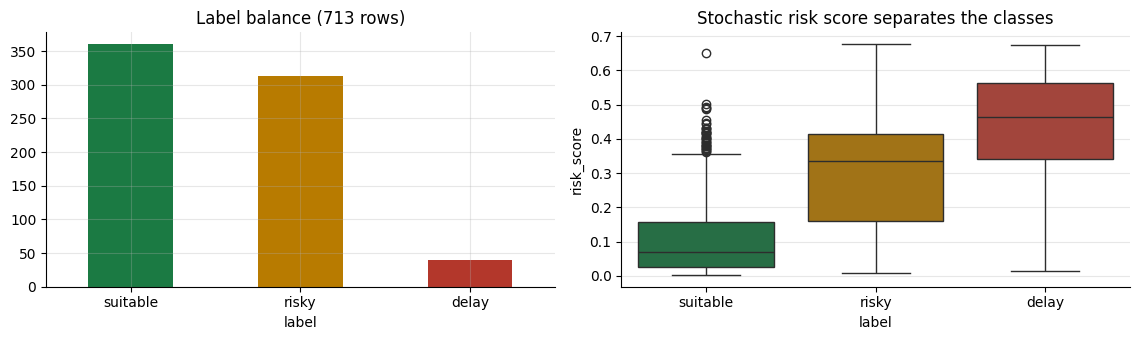

,year,crop,window_start_dekad,cum_rain_since_sep1,pre_tmax_anom,p_rain_sufficient,p_dry_spell,risk_score,label
546,2012,maize,28,105.0,0.044,0.781,0.004,0.111,suitable
223,1994,beans,28,91.4,-0.054,0.992,0.008,0.008,suitable
403,2004,beans,28,88.6,1.285,0.993,0.009,0.101,risky
8,1982,maize,29,120.7,-0.522,0.567,0.002,0.217,suitable
394,2003,maize,33,279.3,0.217,0.252,0.012,0.378,risky
120,1988,maize,31,240.8,-0.541,0.178,0.001,0.411,risky
377,2002,beans,33,262.7,1.317,0.032,0.011,0.649,delay
373,2002,beans,31,194.1,1.317,0.704,0.000,0.243,risky


In [8]:
from dataset import build, RAW_FEATURES, RISK_FEATURES
table, gen_train = build(df)          # ~1–2 min: 713 × 1,000 Monte Carlo runs
print(f"{len(table)} rows | features: {len(RAW_FEATURES)} raw + {len(RISK_FEATURES)} stochastic")
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.5))
table.label.value_counts().reindex(["suitable", "risky", "delay"]).plot.bar(
    ax=axes[0], color=[GREEN, AMBER, RED], rot=0, title="Label balance (713 rows)")
sns.boxplot(data=table, x="label", y="risk_score", order=["suitable", "risky", "delay"],
            hue="label", palette=[GREEN, AMBER, RED], legend=False, ax=axes[1])
axes[1].set_title("Stochastic risk score separates the classes")
plt.tight_layout(); plt.savefig(FIG / "labels.png", bbox_inches="tight"); plt.show()
table[["year", "crop", "window_start_dekad", "cum_rain_since_sep1", "pre_tmax_anom",
       "p_rain_sufficient", "p_dry_spell", "risk_score", "label"]].sample(8, random_state=1)

## 4 · Model architecture

Four model versions

| # | model | input features | purpose |
|---|---|---|---|
| 1 | **Rule-based baseline** | fixed agronomic thresholds (climatological cycle rain vs crop minimum, onset state) | are simple rules enough? |
| 2 | **Decision Tree — raw** | 12 raw pre-window climate features | basic ML without the stochastic layer |
| 3 | **Decision Tree — risk** | 6 stochastic risk features | do risk features improve an interpretable model? |
| 4 | **XGBoost — full** | raw + risk (18 features) | the strongest proposed model |

**XGBoost architecture:** gradient-boosted decision trees, `multi:softprob`
objective over 3 classes — an additive ensemble where each new tree fits the
gradient of the multi-class log-loss. Configuration: **200 trees, max depth 2,
learning rate 0.03**, subsample 0.9, colsample 0.9, L2 λ=1, inverse-frequency
class weights for the rare *delay* class. Shallow depth-2 trees regularize
heavily — the right capacity for ~580 training rows.

**Validation:** temporal hold-out — train 1982–2014 (580 rows), test 2015–2023
(133 rows). Never shuffled: planting advice must generalize forward in time.

In [9]:
from model import compare_models
report, fitted = compare_models(table)
names = {"rule_baseline": "1 · Rule-based baseline", "dt_raw": "2 · Decision Tree — raw",
         "dt_risk": "3 · Decision Tree — risk", "xgb_full": "4 · XGBoost — full"}
cmp = pd.DataFrame({n: {"macro F1": report[k]["macro_f1"],
                        "balanced accuracy": report[k]["balanced_accuracy"],
                        "Brier score (lower = better)": report[k]["brier_score"]}
                    for k, n in names.items()}).T
cmp.style.background_gradient(cmap="Greens", subset=["macro F1", "balanced accuracy"]) \
   .background_gradient(cmap="Greens_r", subset=["Brier score (lower = better)"]).format("{:.3f}")

,macro F1,balanced accuracy,Brier score (lower = better)
1 · Rule-based baseline,0.320,0.340,1.068
2 · Decision Tree — raw,0.463,0.542,0.923
3 · Decision Tree — risk,0.526,0.632,0.937
4 · XGBoost — full,0.642,0.706,0.556


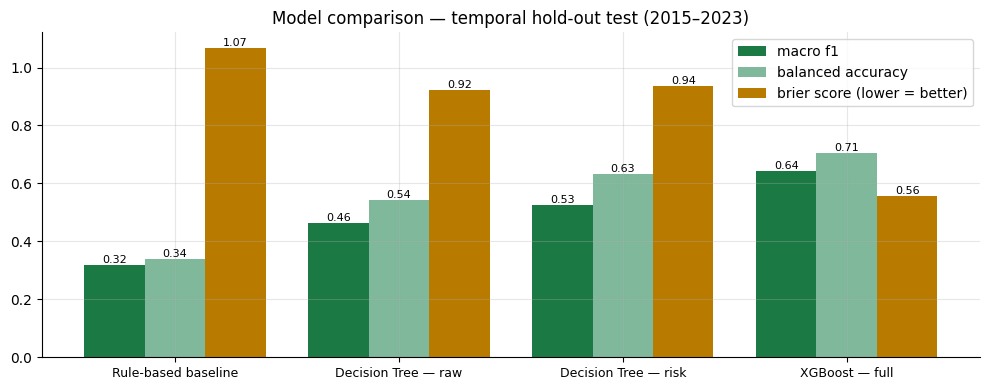

In [10]:
# Model comparison bar chart
x = np.arange(4); wd = 0.27
fig, ax = plt.subplots(figsize=(10, 4))
for i, (metric, col) in enumerate([("macro_f1", GREEN), ("balanced_accuracy", "#7fb89a"),
                                   ("brier_score", AMBER)]):
    vals = [report[k][metric] for k in names]
    bars = ax.bar(x + (i - 1) * wd, vals, wd, color=col,
                  label=metric.replace("_", " ") + (" (lower = better)" if metric == "brier_score" else ""))
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([n.split("· ")[1] for n in names.values()], fontsize=9)
ax.legend(); ax.set_title("Model comparison — temporal hold-out test (2015–2023)")
plt.tight_layout(); plt.savefig(FIG / "model_comparison.png", bbox_inches="tight"); plt.show()

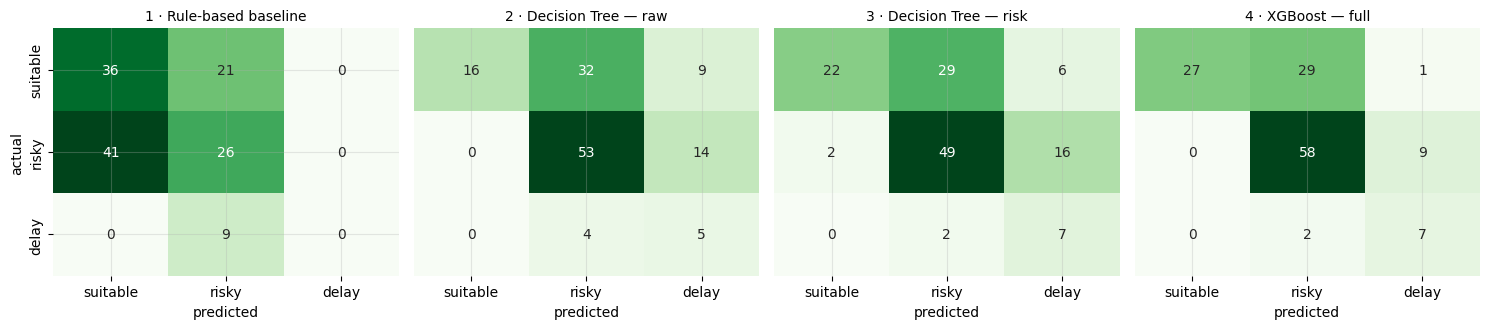

In [11]:
# Confusion matrices — all four models on the 2015–2023 test set
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, (k, n) in zip(axes, names.items()):
    cm = np.array(report[k]["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax,
                xticklabels=report[k]["confusion_matrix_labels"],
                yticklabels=report[k]["confusion_matrix_labels"] if k == "rule_baseline" else False)
    ax.set_title(n, fontsize=10); ax.set_xlabel("predicted")
axes[0].set_ylabel("actual")
plt.tight_layout(); plt.savefig(FIG / "confusion_matrices.png", bbox_inches="tight"); plt.show()

XGBoost per-class metrics (test 2015–2023):


,precision,recall,f1,support
suitable,1.000,0.474,0.643,57.0
risky,0.652,0.866,0.744,67.0
delay,0.412,0.778,0.538,9.0


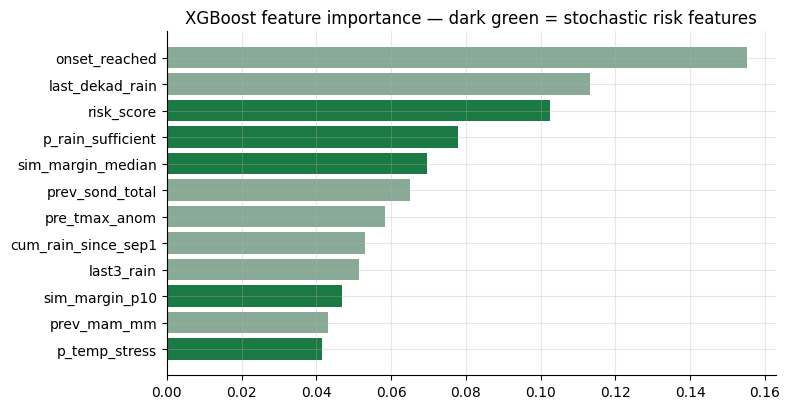

In [12]:
# Per-class precision / recall for the selected model + feature importance
per = pd.DataFrame(report["xgb_full"]["per_class"]).T
print("XGBoost per-class metrics (test 2015–2023):"); display(per)
fi = pd.Series(report["xgb_full"]["feature_importance"]).head(12)[::-1]
plt.figure(figsize=(8, 4.2))
plt.barh(fi.index, fi.values,
         color=[GREEN if f in RISK_FEATURES else "#88aa96" for f in fi.index])
plt.title("XGBoost feature importance — dark green = stochastic risk features")
plt.tight_layout(); plt.savefig(FIG / "feature_importance.png", bbox_inches="tight"); plt.show()

## 5 · Results and answers to the research questions

| model | macro F1 | balanced acc. | Brier ↓ |
|---|---|---|---|
| Rule-based baseline | 0.320 | 0.340 | 1.068 |
| Decision Tree — raw | 0.463 | 0.542 | 0.923 |
| Decision Tree — risk | 0.526 | 0.632 | 0.937 |
| **XGBoost — full (selected)** | **0.642** | **0.706** | **0.556** |



- **RQ1** — historical ENACTS data *can* be transformed into planting-relevant risk
  indicators (sections 1–2).
- **RQ2** — the Monte Carlo layer directly estimates P(sufficient rainfall) per
  crop × window (e.g. ~97% for maize planted 1–10 Sep, ~31% planted 21–30 Nov).
- **RQ3 — yes**: stochastic risk features lift the Decision Tree from 0.463 to
  0.526 macro F1 (balanced accuracy 0.542 → 0.632).
- **RQ4 — yes**: XGBoost beats both trees and the rule baseline on every metric,
  and its Brier score (0.556 vs 0.92+) means its *probabilities* — the heart of
  risk-aware advice — are far better calibrated.
- **RQ5** — the model is deployed as a FastAPI service (Swagger UI + web page);
  see README and `app.py`.

**Honest limitations:** district-average smoothed data understates local extremes;
the rare *delay* class (40/713) has weak recall; temperature stress is an anomaly
proxy, not a physiological threshold; thresholds need RAB validation; no ENSO
covariates yet (the 2015/16 El Niño dominates test-period heat stress).